In [1]:
# Install dependencies
!pip install -U transformers accelerate bitsandbytes pillow numpy pandas scikit-image opencv-python tqdm matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-7khjgxu8
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-7khjgxu8
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [2]:
!git clone https://github.com/bowang-lab/MedSAM.git

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 19.21 MiB/s, done.
Resolving deltas: 100% (474/474), done.


In [3]:
%cd MedSAM

/content/MedSAM


In [4]:
!pip install -e .

Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.6 MB/s eta 0:00:00
  Running setup.py develop for medsam


In [5]:
%cd ..

!unzip Datasets.zip -d datasets

/content
Archive:  Datasets-20260310T200206Z-3-001.zip
  inflating: datasets/Datasets/CVC-ClinicDB/test/masks/29.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/14.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/18.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/30.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/1.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/26.jpg  
  inflating: datasets/Datasets/Kvasir-SEG/test/masks/30.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/17.jpg  
  inflating: datasets/Datasets/CVC-ClinicDB/test/images/2.jpg  
  inflating: datasets/Datasets/CVC-ClinicDB/test/masks/39.jpg  
  inflating: datasets/Datasets/CVC-ColonDB/test/images/37.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/2.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/9.jpg  
  inflating: datasets/Datasets/ETIS-LaribPolypDB/validation/masks/5.jpg  
  inflating

In [6]:
!mv datasets/Datasets/ .

In [7]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")  # or replace with your token string
login(hf_token)
print("HF login done")

HF login done


In [8]:
# Results
OUTPUT_DIR = "/content/polyp_medgemma_medsam_results"

# Put your MedSAM checkpoint here
MEDSAM_CKPT = "/content/medsam_vit_b.pth"

# MedGemma model
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"

# Datasets
DATASET_DIRS = [
    "/content/Datasets/CVC-ClinicDB",
    "/content/Datasets/CVC-ColonDB",
    "/content/Datasets/ETIS-LaribPolypDB",
    "/content/Datasets/Kvasir-SEG"
]

In [9]:
!pwd

/content


In [18]:
# RETRIEVAL
import os
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import (
    AutoProcessor,
    AutoModel,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
)

In [53]:
# Folder containing the retrieval database images
IMAGE_FOLDER = "/content/Datasets/Kvasir-SEG/train/images"

# Query image path
QUERY_IMAGE = "/content/Datasets/Kvasir-SEG/train/images/0.jpg"
# Where to save index files
INDEX_CSV = "/content/retrieval_index.csv"
EMBED_NPY = "/content/retrieval_embeddings.npy"

# Embedding model for retrieval
RETRIEVAL_MODEL_ID = "google/medsiglip-448"

# Explanation model
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"

In [54]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_images_recursive(folder):
    folder = Path(folder)
    files = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            files.append(str(p))
    return sorted(files)

def open_rgb(path):
    return Image.open(path).convert("RGB")

def get_image_embedding(model, processor, image_path, device):
    img = open_rgb(image_path)
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.get_image_features(**inputs)

    if isinstance(out, torch.Tensor):
        emb = out.detach().cpu().numpy().squeeze()
    elif hasattr(out, "image_embeds") and out.image_embeds is not None:
        emb = out.image_embeds.detach().cpu().numpy().squeeze()
    elif hasattr(out, "pooler_output") and out.pooler_output is not None:
        emb = out.pooler_output.detach().cpu().numpy().squeeze()
    else:
        emb = out.last_hidden_state[:, 0].detach().cpu().numpy().squeeze()

    emb = emb.astype(np.float32)
    emb = emb / (np.linalg.norm(emb) + 1e-8)
    return emb

def show_results(query_path, results, cols=3, figsize=(16, 8)):
    n = len(results) + 1
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)

    plt.subplot(rows, cols, 1)
    plt.imshow(open_rgb(query_path))
    plt.title("Query")
    plt.axis("off")

    for i, item in enumerate(results, start=2):
        plt.subplot(rows, cols, i)
        plt.imshow(open_rgb(item["image_path"]))
        plt.title(f"Rank {item['rank']}\nSim={item['similarity']:.4f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [55]:
def build_retrieval_index(
    image_folder,
    model_id="google/medsiglip-448",
    index_csv="/content/retrieval_index.csv",
    embed_npy="/content/retrieval_embeddings.npy",
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    image_paths = list_images_recursive(image_folder)
    print("Found images:", len(image_paths))

    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    rows = []
    embeds = []

    for img_path in tqdm(image_paths, desc="Indexing"):
        try:
            emb = get_image_embedding(model, processor, img_path, device)
            embeds.append(emb)
            rows.append({
                "image_path": img_path,
                "image_name": os.path.basename(img_path),
            })
        except Exception as e:
            print(f"Skip {img_path}: {e}")

    if len(embeds) == 0:
        raise ValueError("No embeddings created.")

    embeddings = np.vstack(embeds)
    index_df = pd.DataFrame(rows)

    np.save(embed_npy, embeddings)
    index_df.to_csv(index_csv, index=False)

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Saved:", index_csv, embed_npy)
    return index_df, embeddings

In [56]:
index_df, embeddings = build_retrieval_index(
    image_folder=IMAGE_FOLDER,
    model_id=RETRIEVAL_MODEL_ID,
    index_csv=INDEX_CSV,
    embed_npy=EMBED_NPY,
)

Device: cuda
Found images: 800


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Indexing: 100%|██████████| 800/800 [04:57<00:00,  2.69it/s]


Saved: /content/retrieval_index.csv /content/retrieval_embeddings.npy


In [57]:
def retrieve_similar_images(
    query_image_path,
    index_csv="/content/retrieval_index.csv",
    embed_npy="/content/retrieval_embeddings.npy",
    model_id="google/medsiglip-448",
    top_k=5,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    index_df = pd.read_csv(index_csv)
    embeddings = np.load(embed_npy)

    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    query_emb = get_image_embedding(model, processor, query_image_path, device)
    sims = cosine_similarity([query_emb], embeddings)[0]

    order = np.argsort(sims)[::-1]

    results = []
    rank = 1
    query_abs = os.path.abspath(query_image_path)

    for idx in order:
        candidate_path = index_df.iloc[idx]["image_path"]
        if os.path.abspath(candidate_path) == query_abs:
            continue

        results.append({
            "rank": rank,
            "image_path": candidate_path,
            "image_name": index_df.iloc[idx]["image_name"],
            "similarity": float(sims[idx]),
        })
        rank += 1

        if len(results) >= top_k:
            break

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

In [58]:
results = retrieve_similar_images(
    query_image_path=QUERY_IMAGE,
    index_csv=INDEX_CSV,
    embed_npy=EMBED_NPY,
    model_id=RETRIEVAL_MODEL_ID,
    top_k=5,
)

pd.DataFrame(results)

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

,rank,image_path,image_name,similarity
0,1,/content/Datasets/Kvasir-SEG/train/images/575.jpg,575.jpg,0.937755
1,2,/content/Datasets/Kvasir-SEG/train/images/621.jpg,621.jpg,0.927581
2,3,/content/Datasets/Kvasir-SEG/train/images/113.jpg,113.jpg,0.923020
3,4,/content/Datasets/Kvasir-SEG/train/images/146.jpg,146.jpg,0.922388
4,5,/content/Datasets/Kvasir-SEG/train/images/737.jpg,737.jpg,0.921961


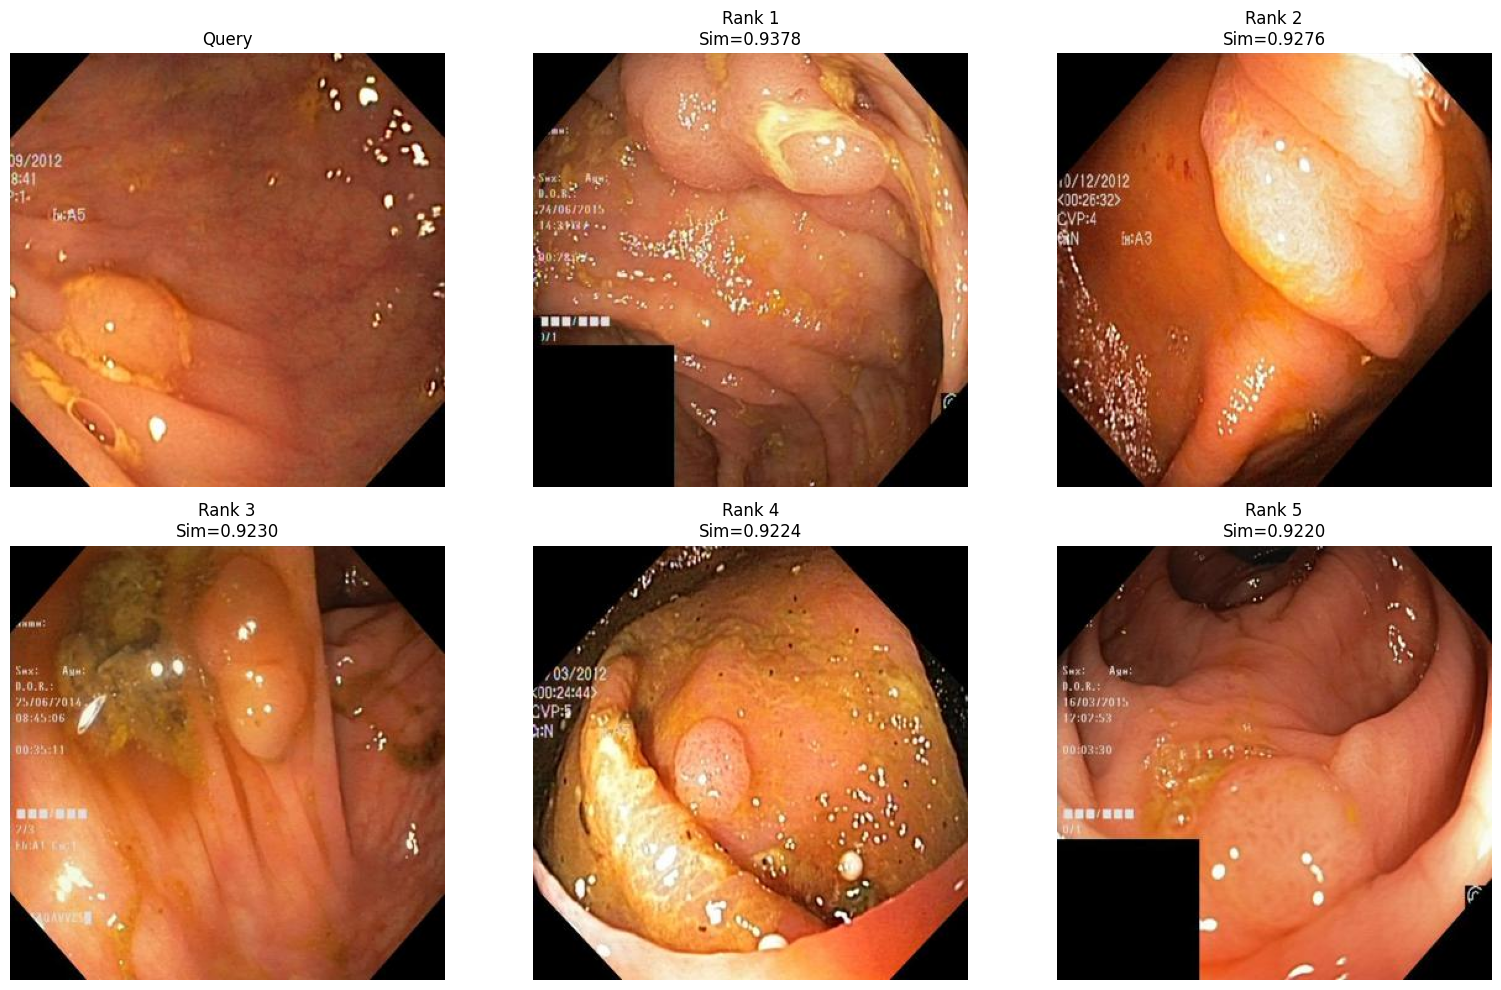

In [59]:
show_results(QUERY_IMAGE, results, cols=3, figsize=(16, 10))

In [60]:
class MedGemmaSimilarityExplainer:
    def __init__(self, model_id="google/medgemma-4b-it", use_4bit=True):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        if use_4bit:
            bnb = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
            self.model = AutoModelForImageTextToText.from_pretrained(
                model_id,
                quantization_config=bnb,
                device_map="auto",
            )
        else:
            self.model = AutoModelForImageTextToText.from_pretrained(
                model_id,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None,
            )

        self.processor = AutoProcessor.from_pretrained(model_id)

    @torch.inference_mode()
    def explain_pair(self, query_image_path, retrieved_image_path):
        query_img = open_rgb(query_image_path)
        retrieved_img = open_rgb(retrieved_image_path)

        prompt = (
            "You are a medical imaging assistant.\n"
            "Compare these two endoscopic or colonoscopy images.\n"
            "Explain briefly why they are medically similar.\n"
            "Focus on visible features such as:\n"
            "- polyp presence\n"
            "- shape\n"
            "- border\n"
            "- color\n"
            "- texture\n"
            "- protrusion\n"
            "- mucosal pattern\n"
            "Give a short educational explanation in 3 to 5 sentences.\n"
            "Do not diagnose with certainty. Say 'may be consistent with' when needed."
        )

        messages = [{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": query_img},
                {"type": "image", "image": retrieved_img},
            ],
        }]

        inputs = self.processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )

        inputs = {k: v.to(self.model.device) if hasattr(v, "to") else v for k, v in inputs.items()}

        output = self.model.generate(
            **inputs,
            max_new_tokens=180,
            do_sample=False,
        )

        response = self.processor.decode(
            output[0][inputs["input_ids"].shape[-1]:],
            skip_special_tokens=True,
        )
        return response.strip()

In [61]:
explainer = MedGemmaSimilarityExplainer(
    model_id=MEDGEMMA_MODEL_ID,
    use_4bit=True,
)

for item in results:
    reason = explainer.explain_pair(QUERY_IMAGE, item["image_path"])
    item["medical_reason"] = reason
    print(f"\nRank {item['rank']} | {item['image_name']} | sim={item['similarity']:.4f}")
    print(reason)
    print("-" * 100)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]


Rank 1 | 575.jpg | sim=0.9378
Based on the provided images, both show what appear to be polyps. The polyps are visible as raised, yellowish-orange structures protruding from the mucosal surface. The borders of the polyps are not clearly defined in the images, and the texture appears somewhat irregular.

These findings may be consistent with the presence of polyps. Further evaluation, such as biopsy, would be needed to confirm the diagnosis and determine the type of polyp.
----------------------------------------------------------------------------------------------------

Rank 2 | 621.jpg | sim=0.9276
Based on the provided images, both show a polyp. The polyp appears to be a yellowish, slightly irregular mass protruding from the colon wall. The border of the polyp is not clearly defined in either image.

Both images may be consistent with a polyp.

Polyp is a growth that arises from the colon lining.
-------------------------------------------------------------------------------------

In [62]:
df_results = pd.DataFrame(results)
df_results

,rank,image_path,image_name,similarity,medical_reason
0,1,/content/Datasets/Kvasir-SEG/train/images/575.jpg,575.jpg,0.937755,"Based on the provided images, both show what a..."
1,2,/content/Datasets/Kvasir-SEG/train/images/621.jpg,621.jpg,0.927581,"Based on the provided images, both show a poly..."
2,3,/content/Datasets/Kvasir-SEG/train/images/113.jpg,113.jpg,0.923020,"Based on the provided images, both show what a..."
3,4,/content/Datasets/Kvasir-SEG/train/images/146.jpg,146.jpg,0.922388,"Based on the provided images, both show a poly..."
4,5,/content/Datasets/Kvasir-SEG/train/images/737.jpg,737.jpg,0.921961,"Based on the provided images, both show a visi..."


In [63]:
SAVE_CSV = "/content/retrieval_with_medical_reasons.csv"
df_results.to_csv(SAVE_CSV, index=False)
print("Saved to:", SAVE_CSV)

Saved to: /content/retrieval_with_medical_reasons.csv
